# Unconstrained GMV — Fair Comparison (no long-only, no weight cap)

**Goal**: Compare the three GMV strategies with **unconstrained** weights so that
the only difference is the quality of the covariance estimate.

## Formula (unconstrained analytical GMV)
$$w^* = \frac{\Sigma^{-1} \mathbf{1}}{\mathbf{1}^\top \Sigma^{-1} \mathbf{1}}$$

Weights can be negative (short positions). No cap constraint.

## Strategies compared
1. **GMV-GARCH** — GARCH(1,1) vols + rolling correlation — analytical inverse
2. **GMV-NN** — CNN-GARCH vols + rolling correlation — analytical inverse
3. **GMV-NN-Clean** — CNN-GARCH vols + RIENet-cleaned eigen decomposition — `EigenWeightsLayer`

All three use the same unconstrained analytical solution for a fair comparison.


In [1]:
from __future__ import annotations
import warnings, sys, time
import numpy as np
import pandas as pd
import torch
import tensorflow as tf
import matplotlib.pyplot as plt
import cvxpy as cp

warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

from model import HybridGarch
from data_stocks_WIKI_price import get_cleaned_data
from rienet_torch import CorrelationEigenTransformLayer, EigenWeightsLayer

print(f'TensorFlow {tf.__version__} | NumPy {np.__version__} | cvxpy {cp.__version__} | PyTorch {torch.__version__}')


TensorFlow 2.20.0 | NumPy 2.4.3 | cvxpy 1.8.2 | PyTorch 2.10.0+cpu


In [2]:
pip install rienet_torch


Note: you may need to restart the kernel to use updated packages.


In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
FILE_PATH   = r'C:/Users/karim/OneDrive/Documents/Msc AI/Finance/TP/WIKI_PRICES_212b326a081eacca455e13140d7bb9db.zip'
CHECKPOINT  = r'../finetune_real_zeroaware_r2min1e8_best.weights.h5'

WINDOW_SIZE = 90      # rolling window — CNN input & correlation window
N_STOCKS    = 50
TRAIN_RATIO = 0.70
ANNUALIZE   = 252
# No weight constraints — unconstrained GMV (weights can be negative)

print(f'Window : {WINDOW_SIZE} | Unconstrained GMV')


Window : 90 | Unconstrained GMV


## 1. Data Loading

In [4]:
returns_df_full = get_cleaned_data(FILE_PATH)
print(f'Full universe : {returns_df_full.shape[0]} days x {returns_df_full.shape[1]} stocks')
print(f'Date range    : {returns_df_full.index[0].date()} -> {returns_df_full.index[-1].date()}')

# Select first N_STOCKS (same as Portfolio.ipynb)
selected   = returns_df_full.columns[:N_STOCKS].tolist()
returns_df = returns_df_full[selected].copy()
print(f'\nPortfolio : {N_STOCKS} stocks -> {selected[:5]} ...')

[get_cleaned_data] Universe after filters : 1338 stocks (price≥$3.0 on 2012-10-04, max consec zeros ≤ 20)
Full universe : 4585 days x 1338 stocks
Date range    : 2000-01-04 -> 2018-03-27

Portfolio : 50 stocks -> ['A', 'AAN', 'AAON', 'AAPL', 'ABAX'] ...


## 2. Train / Test Split

In [5]:
n_total   = len(returns_df)
split_idx = int(TRAIN_RATIO * n_total)
start_t   = max(WINDOW_SIZE, split_idx)

returns_train = returns_df.iloc[:split_idx]
returns_test  = returns_df.iloc[split_idx:]
test_dates    = returns_df.index[start_t:]

returns_arr  = returns_df.values.astype(np.float32)   # [T, N]
train_means  = returns_train.mean().values.astype(np.float32)
train_stds   = returns_train.std(ddof=0).values.astype(np.float32)

print(f'Train : {returns_train.index[0].date()} -> {returns_train.index[-1].date()} ({len(returns_train)} days)')
print(f'Test  : {returns_test.index[0].date()}  -> {returns_test.index[-1].date()}  ({len(returns_test)} days)')
print(f'start_t = {start_t} | test_len = {len(test_dates)}')

Train : 2000-01-04 -> 2012-10-03 (3209 days)
Test  : 2012-10-04  -> 2018-03-27  (1376 days)
start_t = 3209 | test_len = 1376


## 3. Load CNN-GARCH Model

In [6]:
model = HybridGarch(hidden=32, kernel=3, conv_layers=5)
# Build the model with a dummy input so weights are created before loading
dummy_input = tf.zeros((1, WINDOW_SIZE, 1))
_ = model(dummy_input, training=False)
model.load_weights(CHECKPOINT)
print(f'Model loaded : {model.count_params():,} parameters')

Model loaded : 14,499 parameters


## 4. Volatility Estimation Functions

In [7]:
def _predict_nn_batch(windows_norm, model):
    x = tf.constant(windows_norm, dtype=tf.float32)
    x = tf.expand_dims(x, axis=-1)  # [N, W, 1]
    sigma2_norm, _, _, _ = model(x, training=False)
    return sigma2_norm.numpy()


def precompute_sigma2_nn(returns_arr, train_means, train_stds, model,
                         window_size, start_t, annualize=252):
    T, N = returns_arr.shape
    sigma2_mat = np.full((T - start_t, N), np.nan)
    eps = 1e-8
    for k, t in enumerate(range(start_t, T)):
        windows = returns_arr[t - window_size:t, :]
        if np.isnan(windows).any():
            continue
        wn = (windows.T - train_means[:, None]) / (train_stds[:, None] + eps)
        s2 = _predict_nn_batch(wn, model) * (train_stds + eps) ** 2
        sigma2_mat[k] = np.clip(s2, 1e-10, None) * annualize
    return sigma2_mat


def precompute_sigma2_arch(returns_arr, train_means, split_idx, start_t, annualize=252):
    from arch import arch_model as arch_fit
    T, N = returns_arr.shape
    sigma2_mat = np.zeros((T - start_t, N))
    for j in range(N):
        r_j = returns_arr[:split_idx, j].astype(np.float64)
        try:
            res = arch_fit(r_j * 100, mean='Zero', vol='GARCH', p=1, q=1).fit(disp='off')
            omega = res.params['omega'] / 1e4
            alpha = res.params['alpha[1]']
            beta  = res.params['beta[1]']
            s2    = float(res.conditional_volatility[-1] ** 2)
        except Exception:
            omega, alpha, beta = 1e-6, 0.05, 0.90
            s2 = np.var(r_j, ddof=0)
        for t in range(split_idx, T):
            s2 = omega + alpha * returns_arr[t-1, j]**2 + beta * s2
            s2 = max(s2, 1e-10)
            if t >= start_t:
                sigma2_mat[t - start_t, j] = s2 * annualize
    return sigma2_mat


print('Volatility functions defined.')

Volatility functions defined.


## 5. Compute Sigma² Matrices

In [8]:
print('[1/2] CNN-GARCH forward pass...')
t0 = time.time()
sigma2_nn = precompute_sigma2_nn(
    returns_arr, train_means, train_stds, model, WINDOW_SIZE, start_t, ANNUALIZE
)
print(f'      OK ({time.time()-t0:.1f}s)')

print('[2/2] GARCH(1,1) recursion...')
t0 = time.time()
sigma2_arch = precompute_sigma2_arch(
    returns_arr.astype(np.float64), train_means, split_idx, start_t, ANNUALIZE
)
print(f'      OK ({time.time()-t0:.1f}s)')

print(f'\nShape: {sigma2_nn.shape}  [test_days x N_stocks]')

[1/2] CNN-GARCH forward pass...
      OK (70.6s)
[2/2] GARCH(1,1) recursion...
      OK (1.8s)

Shape: (1376, 50)  [test_days x N_stocks]


## 6. GMV Portfolio Optimization

### Unconstrained Analytical Solution

At each day $t$:
$$\Sigma(t) = D(t) \cdot \hat{C}_{t-90:t} \cdot D(t)$$
$$w^*(t) = \frac{\Sigma(t)^{-1} \mathbf{1}}{\mathbf{1}^\top \Sigma(t)^{-1} \mathbf{1}}$$

- **GMV-GARCH / GMV-NN**: direct matrix inversion (Cholesky solve)
- **GMV-NN-Clean**: `EigenWeightsLayer` on RIENet-cleaned eigendecomposition


In [9]:
def rolling_correlation(returns_arr, t, window_size):
    """Sample correlation matrix from returns[t-window:t]."""
    window = returns_arr[t - window_size:t, :]
    w = window - window.mean(axis=0)
    cov = (w.T @ w) / (window_size - 1)
    std = np.maximum(np.sqrt(np.diag(cov)), 1e-10)
    corr = cov / np.outer(std, std)
    corr = np.clip(corr, -1.0, 1.0)
    np.fill_diagonal(corr, 1.0)
    return corr


def nearest_psd(cov, reg=1e-6):
    """Clip negative eigenvalues -> guaranteed PSD."""
    cov = (cov + cov.T) / 2
    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.maximum(eigvals, reg)
    cov_psd = eigvecs @ np.diag(eigvals) @ eigvecs.T
    return (cov_psd + cov_psd.T) / 2


# ── RIENet layers ─────────────────────────────────────────────────────────────
corr_cleaner = CorrelationEigenTransformLayer(name="corr_cleaner")
weight_layer  = EigenWeightsLayer(name="gmv_weights")
print('RIENet layers ready: CorrelationEigenTransformLayer + EigenWeightsLayer')


def build_covariance(sigma2_daily, corr):
    """Build covariance from vols + rolling correlation."""
    sigma_daily = np.sqrt(np.maximum(sigma2_daily / ANNUALIZE, 1e-10))
    D = np.diag(sigma_daily)
    return nearest_psd(D @ corr @ D)


def gmv_weights_unconstrained(cov):
    """Analytical unconstrained GMV: w* = Sigma^-1 1 / (1' Sigma^-1 1).
    Weights can be negative. Uses Cholesky solve for numerical stability.
    """
    N = cov.shape[0]
    ones = np.ones(N)
    cov_psd = nearest_psd(cov)
    try:
        L = np.linalg.cholesky(cov_psd)
        # Solve L L^T w = 1  via two triangular solves
        z = np.linalg.solve(L, ones)          # L z = 1
        w = np.linalg.solve(L.T, z)           # L^T w = z  =>  w = Sigma^-1 1
    except np.linalg.LinAlgError:
        w = np.linalg.pinv(cov_psd) @ ones
    denom = w.sum()
    if abs(denom) < 1e-10:
        return ones / N
    return w / denom   # sums to 1, can have negative entries


def gmv_weights_rienet(sigma2_daily, corr, corr_layer, w_layer,
                        q=None, lookback=None):
    """Unconstrained GMV via full RIENet eigen pipeline.

    Step 1 — CorrelationEigenTransformLayer: clean correlation eigenvalues.
    Step 2 — EigenWeightsLayer: w* = D^-1 V Lambda^-1 V^T D^-1 1  (analytical).
    No projection — weights can be negative.
    """
    N = len(sigma2_daily)
    sigma_daily = np.sqrt(np.maximum(sigma2_daily / ANNUALIZE, 1e-10))

    corr_t  = torch.tensor(corr[np.newaxis], dtype=torch.float32)   # (1, N, N)
    inv_std = torch.tensor(
        (1.0 / sigma_daily).reshape(1, N, 1), dtype=torch.float32   # (1, N, 1)
    )

    attrs = None
    attr_cols = []
    if q is not None:
        attr_cols.append(float(q))
    if lookback is not None:
        attr_cols.append(float(lookback))
    if attr_cols:
        attrs = torch.tensor([attr_cols], dtype=torch.float32)

    # Step 1: clean correlation -> eigenvectors + inverse_eigenvalues
    details = corr_layer(
        corr_t,
        attributes=attrs,
        output_type=["eigenvectors", "inverse_eigenvalues"],
    )
    eigvecs  = details["eigenvectors"]          # (1, N, N)
    inv_eigs = details["inverse_eigenvalues"]   # (1, N, 1)

    # Step 2: analytical unconstrained GMV weights
    w_raw = w_layer(eigvecs, inv_eigs, inv_std)  # (1, N)
    w = w_raw[0].detach().numpy().flatten()      # (N,)

    denom = w.sum()
    if abs(denom) < 1e-10:
        return np.ones(N) / N
    return w / denom   # sums to 1, can have negative entries


print('GMV functions defined (all unconstrained — weights can be negative).')
print('  GMV-GARCH / GMV-NN  : Cholesky solve  w* = Sigma^-1 1 / 1T Sigma^-1 1')
print('  GMV-NN-Clean        : EigenWeightsLayer  (RIENet analytical)')


RIENet layers ready: CorrelationEigenTransformLayer + EigenWeightsLayer
GMV functions defined (all unconstrained — weights can be negative).
  GMV-GARCH / GMV-NN  : Cholesky solve  w* = Sigma^-1 1 / 1T Sigma^-1 1
  GMV-NN-Clean        : EigenWeightsLayer  (RIENet analytical)


In [10]:
def compute_gmv_portfolio(sigma2_mat, returns_arr, start_t, window_size,
                          label='GMV', corr_layer=None, w_layer=None):
    """Compute daily GMV portfolio returns and weights (unconstrained).

    GMV-GARCH / GMV-NN  : Cholesky analytical inversion.
    GMV-NN-Clean        : CorrelationEigenTransformLayer + EigenWeightsLayer.
    """
    test_len   = sigma2_mat.shape[0]
    N          = sigma2_mat.shape[1]
    q_ratio    = window_size / N
    use_rienet = (corr_layer is not None) and (w_layer is not None)
    port_returns = np.zeros(test_len)
    weights_hist = np.zeros((test_len, N))

    for k in range(test_len):
        t    = start_t + k
        r_t  = returns_arr[t]
        s2_k = sigma2_mat[k]

        if np.isnan(s2_k).any():
            w = np.ones(N) / N
        elif use_rienet:
            corr = rolling_correlation(returns_arr, t, window_size)
            w = gmv_weights_rienet(
                s2_k, corr,
                corr_layer=corr_layer, w_layer=w_layer,
                q=q_ratio, lookback=float(window_size),
            )
        else:
            corr = rolling_correlation(returns_arr, t, window_size)
            cov  = build_covariance(s2_k, corr)
            w    = gmv_weights_unconstrained(cov)

        port_returns[k] = np.dot(w, r_t)
        weights_hist[k] = w

        if k % 200 == 0:
            short_pct = (w < 0).mean() * 100
            print(f'  [{label}] Day {k}/{test_len} — short={short_pct:.0f}% HHI={(w**2).sum():.3f}')

    return port_returns, weights_hist


print('compute_gmv_portfolio defined (unconstrained).')


compute_gmv_portfolio defined (unconstrained).


## 7. Run All Strategies

In [11]:
print('Computing unconstrained strategies...')

# 1. GMV-GARCH — GARCH vols + raw rolling correlation (Cholesky analytical)
print('  [1/3] GMV-GARCH...')
t0 = time.time()
r_gmv_arch, w_gmv_arch = compute_gmv_portfolio(
    sigma2_arch, returns_arr, start_t, WINDOW_SIZE, label='GMV-GARCH'
)
print(f'        Done ({time.time()-t0:.0f}s)')

# 2. GMV-NN — CNN-GARCH vols + raw rolling correlation (Cholesky analytical)
print('  [2/3] GMV-NN...')
t0 = time.time()
r_gmv_nn, w_gmv_nn = compute_gmv_portfolio(
    sigma2_nn, returns_arr, start_t, WINDOW_SIZE, label='GMV-NN'
)
print(f'        Done ({time.time()-t0:.0f}s)')

# 3. GMV-NN-Clean — CNN-GARCH vols + RIENet EigenWeightsLayer (analytical)
print('  [3/3] GMV-NN-Clean...')
t0 = time.time()
r_gmv_nn_clean, w_gmv_nn_clean = compute_gmv_portfolio(
    sigma2_nn, returns_arr, start_t, WINDOW_SIZE,
    label='GMV-NN-Clean',
    corr_layer=corr_cleaner,
    w_layer=weight_layer,
)
print(f'        Done ({time.time()-t0:.0f}s)')

print('\nAll strategies computed.')


Computing unconstrained strategies...
  [1/3] GMV-GARCH...
  [GMV-GARCH] Day 0/1376 — short=42% HHI=0.531
  [GMV-GARCH] Day 200/1376 — short=44% HHI=0.317
  [GMV-GARCH] Day 400/1376 — short=52% HHI=0.620
  [GMV-GARCH] Day 600/1376 — short=50% HHI=0.862
  [GMV-GARCH] Day 800/1376 — short=48% HHI=1.187
  [GMV-GARCH] Day 1000/1376 — short=46% HHI=0.575
  [GMV-GARCH] Day 1200/1376 — short=48% HHI=0.335
        Done (2s)
  [2/3] GMV-NN...
  [GMV-NN] Day 0/1376 — short=46% HHI=0.614
  [GMV-NN] Day 200/1376 — short=40% HHI=0.561
  [GMV-NN] Day 400/1376 — short=48% HHI=0.782
  [GMV-NN] Day 600/1376 — short=46% HHI=0.741
  [GMV-NN] Day 800/1376 — short=44% HHI=0.926
  [GMV-NN] Day 1000/1376 — short=44% HHI=0.535
  [GMV-NN] Day 1200/1376 — short=52% HHI=0.460
        Done (2s)
  [3/3] GMV-NN-Clean...
  [GMV-NN-Clean] Day 0/1376 — short=0% HHI=0.023
  [GMV-NN-Clean] Day 200/1376 — short=0% HHI=0.021
  [GMV-NN-Clean] Day 400/1376 — short=0% HHI=0.023
  [GMV-NN-Clean] Day 600/1376 — short=0% HHI=0.

## 8. Financial Metrics

In [12]:
def financial_metrics(returns, annualize=252):
    r = pd.Series(returns).dropna()
    ann_ret = r.mean() * annualize
    ann_vol = r.std(ddof=0) * np.sqrt(annualize)
    sharpe  = ann_ret / ann_vol if ann_vol > 1e-10 else np.nan
    cumret  = (1 + r).cumprod()
    max_dd  = float(((cumret - cumret.cummax()) / cumret.cummax()).min())
    calmar  = ann_ret / abs(max_dd) if abs(max_dd) > 1e-10 else np.nan
    return {
        'Ann. Return (%)' : round(ann_ret * 100, 2),
        'Ann. Vol (%)'    : round(ann_vol * 100, 2),
        'Sharpe'          : round(sharpe, 4),
        'Max Drawdown (%)': round(max_dd * 100, 2),
        'Calmar'          : round(calmar, 4),
    }


metrics = pd.DataFrame({
    'GMV-GARCH'    : financial_metrics(r_gmv_arch),
    'GMV-NN'       : financial_metrics(r_gmv_nn),
    'GMV-NN-Clean' : financial_metrics(r_gmv_nn_clean),
}).T

print('=' * 60)
print('OUT-OF-SAMPLE PERFORMANCE')
print('=' * 60)
print(metrics.to_string())
print()

best_vol    = metrics['Ann. Vol (%)'].idxmin()
best_sharpe = metrics['Sharpe'].idxmax()
best_dd     = metrics['Max Drawdown (%)'].idxmax()
print(f'Best Volatility  : {best_vol}')
print(f'Best Sharpe      : {best_sharpe}')
print(f'Best Max Drawdown: {best_dd}')


OUT-OF-SAMPLE PERFORMANCE
              Ann. Return (%)  Ann. Vol (%)  Sharpe  Max Drawdown (%)  Calmar
GMV-GARCH               17.39         13.95  1.2468            -13.21  1.3165
GMV-NN                  20.43         14.40  1.4190            -17.37  1.1761
GMV-NN-Clean            17.53         12.75  1.3755            -15.06  1.1644

Best Volatility  : GMV-NN-Clean
Best Sharpe      : GMV-NN
Best Max Drawdown: GMV-GARCH


## 9. Visualizations (includes short-weight diagnostic)


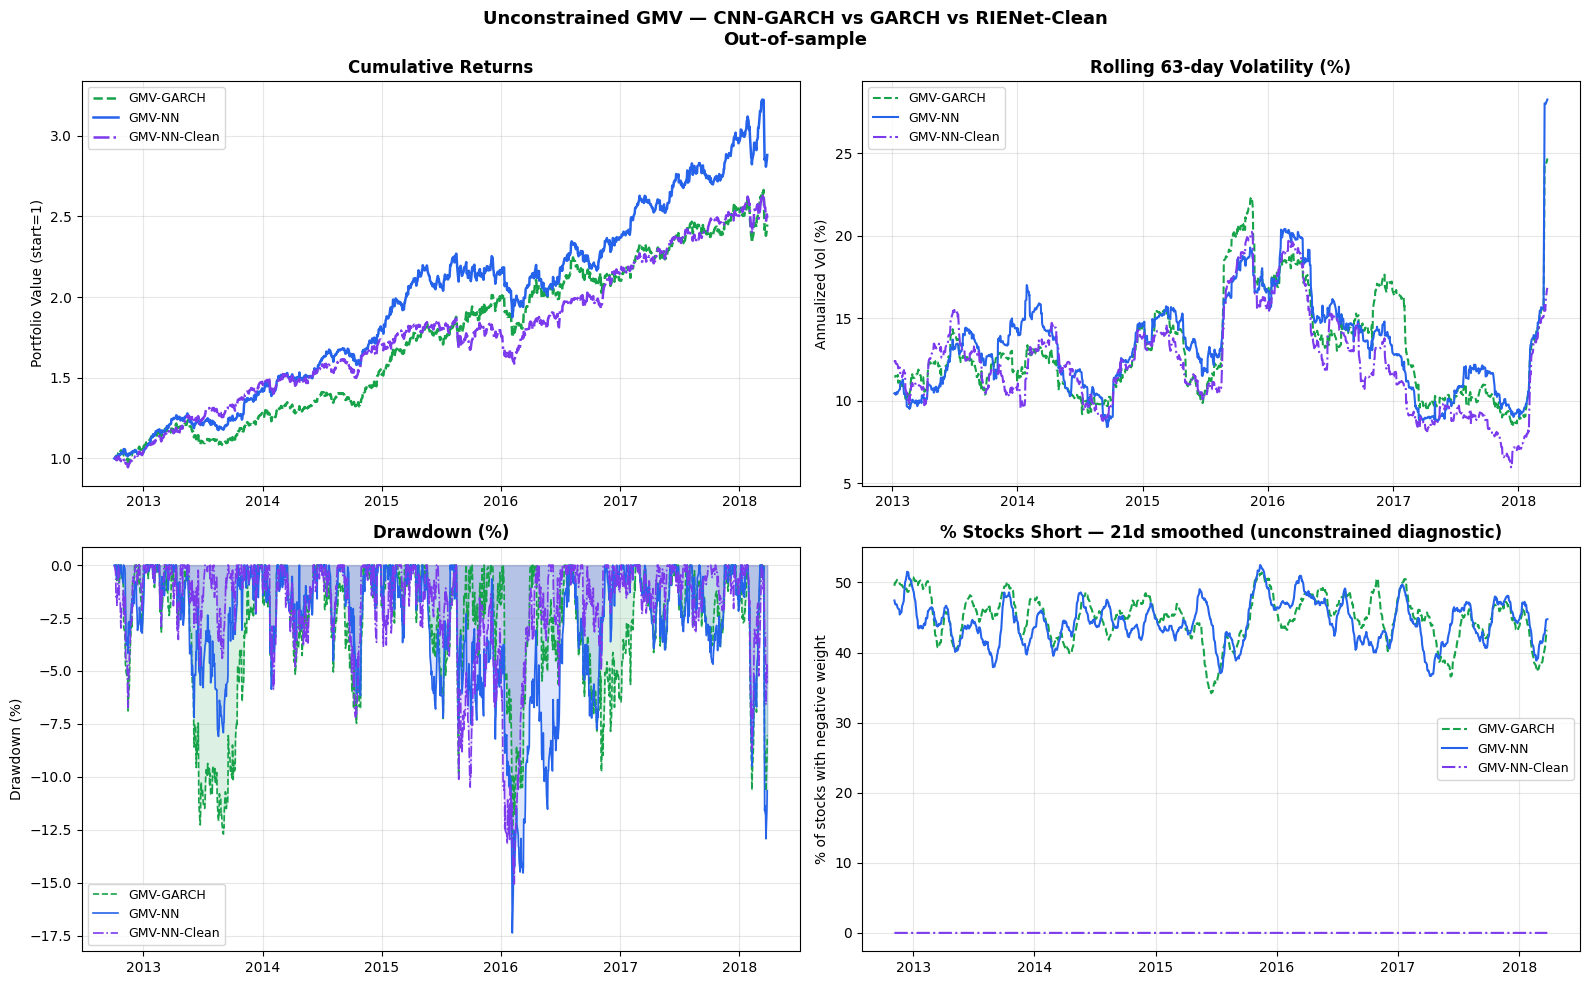

Figure saved: gmv_unconstrained_results.png


In [13]:
_BLUE   = '#2563EB'
_GREEN  = '#16A34A'
_PURPLE = '#7C3AED'

strategies = {
    'GMV-GARCH'    : (r_gmv_arch,      w_gmv_arch,       _GREEN,  '--'),
    'GMV-NN'       : (r_gmv_nn,        w_gmv_nn,         _BLUE,   '-'),
    'GMV-NN-Clean' : (r_gmv_nn_clean,  w_gmv_nn_clean,   _PURPLE, '-.'),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Unconstrained GMV — CNN-GARCH vs GARCH vs RIENet-Clean\nOut-of-sample',
             fontsize=13, fontweight='bold')

# 1. Cumulative returns
ax = axes[0, 0]
for name, (r, w, col, ls) in strategies.items():
    cum = (1 + pd.Series(r, index=test_dates)).cumprod()
    ax.plot(cum.index, cum.values, color=col, linestyle=ls, linewidth=1.8, label=name)
ax.set_title('Cumulative Returns', fontweight='bold')
ax.set_ylabel('Portfolio Value (start=1)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# 2. Rolling 63-day volatility
ax = axes[0, 1]
for name, (r, w, col, ls) in strategies.items():
    roll_vol = pd.Series(r, index=test_dates).rolling(63).std() * np.sqrt(252) * 100
    ax.plot(roll_vol.index, roll_vol.values, color=col, linestyle=ls, linewidth=1.5, label=name)
ax.set_title('Rolling 63-day Volatility (%)', fontweight='bold')
ax.set_ylabel('Annualized Vol (%)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# 3. Drawdown
ax = axes[1, 0]
for name, (r, w, col, ls) in strategies.items():
    cum = (1 + pd.Series(r, index=test_dates)).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    ax.fill_between(dd.index, dd.values, 0, alpha=0.15, color=col)
    ax.plot(dd.index, dd.values, color=col, linestyle=ls, linewidth=1.2, label=name)
ax.set_title('Drawdown (%)', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# 4. Short-weight % over time (diagnostic for unconstrained)
ax = axes[1, 1]
for name, (r, w, col, ls) in strategies.items():
    short_pct = pd.Series((w < 0).mean(axis=1) * 100, index=test_dates)
    ax.plot(short_pct.index, short_pct.rolling(21).mean(),
            color=col, linestyle=ls, linewidth=1.5, label=name)
ax.set_title('% Stocks Short — 21d smoothed (unconstrained diagnostic)', fontweight='bold')
ax.set_ylabel('% of stocks with negative weight')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gmv_unconstrained_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: gmv_unconstrained_results.png')


In [14]:
N_STOCKS

50

## 10. Full Comparison — All 3 Strategies


In [15]:
all_strategies = {
    'GMV-GARCH'    : (r_gmv_arch,      w_gmv_arch),
    'GMV-NN'       : (r_gmv_nn,        w_gmv_nn),
    'GMV-NN-Clean' : (r_gmv_nn_clean,  w_gmv_nn_clean),
}

all_metrics = {name: financial_metrics(r) for name, (r, _) in all_strategies.items()}

print('=' * 80)
print('FULL COMPARISON — UNCONSTRAINED GMV (Out-of-sample)')
print('=' * 80)

header = f"{'Metric':<22}" + ''.join(f'{name:>16}' for name in all_metrics)
print(header)
print('-' * len(header))

metric_names = list(next(iter(all_metrics.values())).keys())
for m in metric_names:
    vals = [all_metrics[name][m] for name in all_metrics]
    row = f'{m:<22}' + ''.join(f'{v:>16}' for v in vals)
    best_name = (min if ('Vol' in m or 'Drawdown' in m) else max)(
        all_metrics, key=lambda n: all_metrics[n][m])
    print(row + f'   <- best: {best_name}')

# Short-weight diagnostics
print(f'\n{"─" * 80}')
print(f'{"SHORT-WEIGHT DIAGNOSTICS":<22}' + ''.join(f'{name:>16}' for name in all_strategies))
print('-' * 80)

short_row   = f'{"Mean % stocks short":<22}'
max_lvg_row = f'{"Max gross leverage":<22}'
for name, (_, w) in all_strategies.items():
    short_pct = (w < 0).mean(axis=1).mean() * 100
    gross_lev = np.abs(w).sum(axis=1).mean()
    short_row   += f'{short_pct:>15.1f}%'
    max_lvg_row += f'{gross_lev:>16.3f}'

print(short_row)
print(max_lvg_row)

print(f'\n{"=" * 80}')
print('EFFECT OF RIENet CLEANING (GMV-NN-Clean vs GMV-NN)')
print('=' * 80)
m_raw   = all_metrics['GMV-NN']
m_clean = all_metrics['GMV-NN-Clean']
for k in metric_names:
    v1, v2 = m_raw[k], m_clean[k]
    if 'Vol' in k or 'Drawdown' in k:
        imp = f'{v1 - v2:+.2f}  (lower is better)' if v2 < v1 else f'{v1 - v2:+.2f}'
    else:
        imp = f'{v2 - v1:+.4f}  (higher is better)' if v2 > v1 else f'{v2 - v1:+.4f}'
    print(f'  {k:<22} {imp}')


FULL COMPARISON — UNCONSTRAINED GMV (Out-of-sample)
Metric                       GMV-GARCH          GMV-NN    GMV-NN-Clean
----------------------------------------------------------------------
Ann. Return (%)                  17.39           20.43           17.53   <- best: GMV-NN
Ann. Vol (%)                     13.95            14.4           12.75   <- best: GMV-NN-Clean
Sharpe                          1.2468           1.419          1.3755   <- best: GMV-NN
Max Drawdown (%)                -13.21          -17.37          -15.06   <- best: GMV-NN
Calmar                          1.3165          1.1761          1.1644   <- best: GMV-GARCH

────────────────────────────────────────────────────────────────────────────────
SHORT-WEIGHT DIAGNOSTICS       GMV-GARCH          GMV-NN    GMV-NN-Clean
--------------------------------------------------------------------------------
Mean % stocks short              45.0%           44.4%            0.0%
Max gross leverage               3.144       

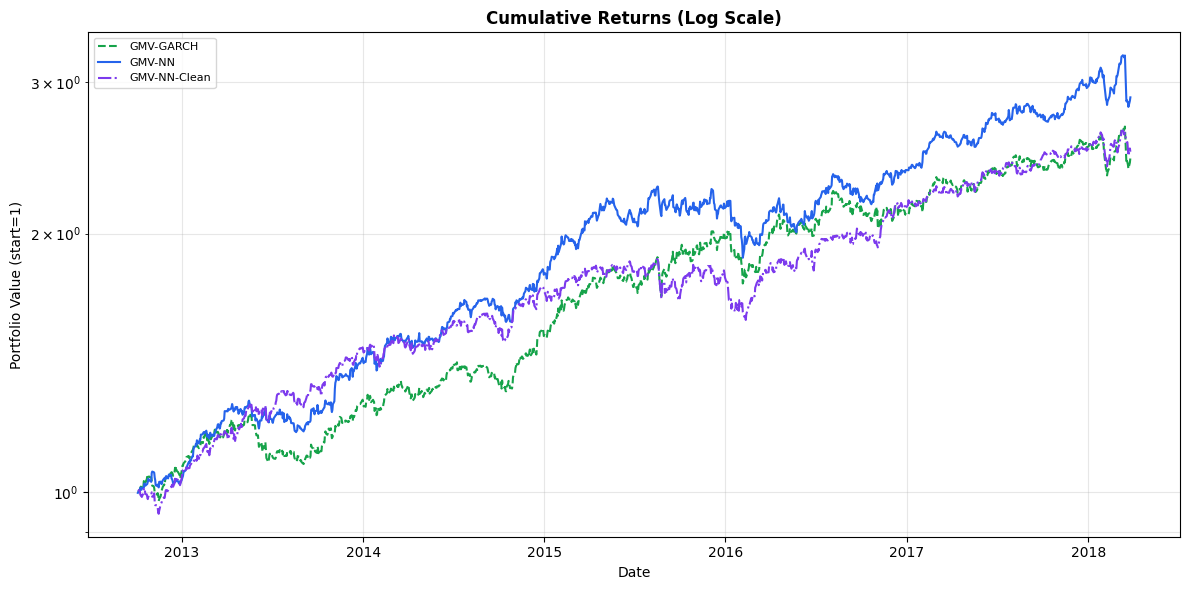

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

for name, (r, _, col, ls) in strategies.items():
    cum = (1 + pd.Series(r, index=test_dates)).cumprod()
    ax.plot(cum.index, cum.values, color=col, linestyle=ls, linewidth=1.5, label=name)

ax.set_yscale('log')
ax.set_title('Cumulative Returns (Log Scale)', fontweight='bold')
ax.set_ylabel('Portfolio Value (start=1)')
ax.set_xlabel('Date')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
fig.savefig('cumulative_returns_log.png', dpi=150, bbox_inches='tight')
plt.show()
